## LOGISTIC REGRESSION

```
1. Data Exploration:
a. Load the dataset and perform exploratory data analysis (EDA).
b. Examine the features, their types, and summary statistics.
c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

2. Data Preprocessing:
a. Handle missing values (e.g., imputation).
b. Encode categorical variables.

3. Model Building:
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
b. Train the model using the training data.

4. Model Evaluation:
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.

5. Interpretation:
a. Interpret the coefficients of the logistic regression model.
b. Discuss the significance of features in predicting the target variable (survival probability in this case).

6. Deployment with Streamlit:
In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions. 

(optional)For online deployment, use Streamlit Community Cloud, which supports deployment from GitHub repositories. 

```

## Answer
```
1. Data Exploration:
a. Load the dataset and perform exploratory data analysis (EDA).
b. Examine the features, their types, and summary statistics.
c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Loading the data to the enviroment
df = pd.read_csv("diabetes.csv")

# making another dataset copy
dataset = df.copy()

#Getting information about the data
print("\n<-----INFO------>\n")
print(dataset.info())

print("\n<-----DESCRIBE NUMERICAL VARIABLES------>\n")
print(dataset.describe())

print("\n<-----DESCRIBE BOTH NUMERICAL AND CATEGORICAL------>\n")
print(dataset.describe(include='all'))

print("\n<-----MISSING VALUES------>\n")
print(dataset.isnull().sum())




<-----INFO------>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

<-----DESCRIBE NUMERICAL VARIABLES------>

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052 

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


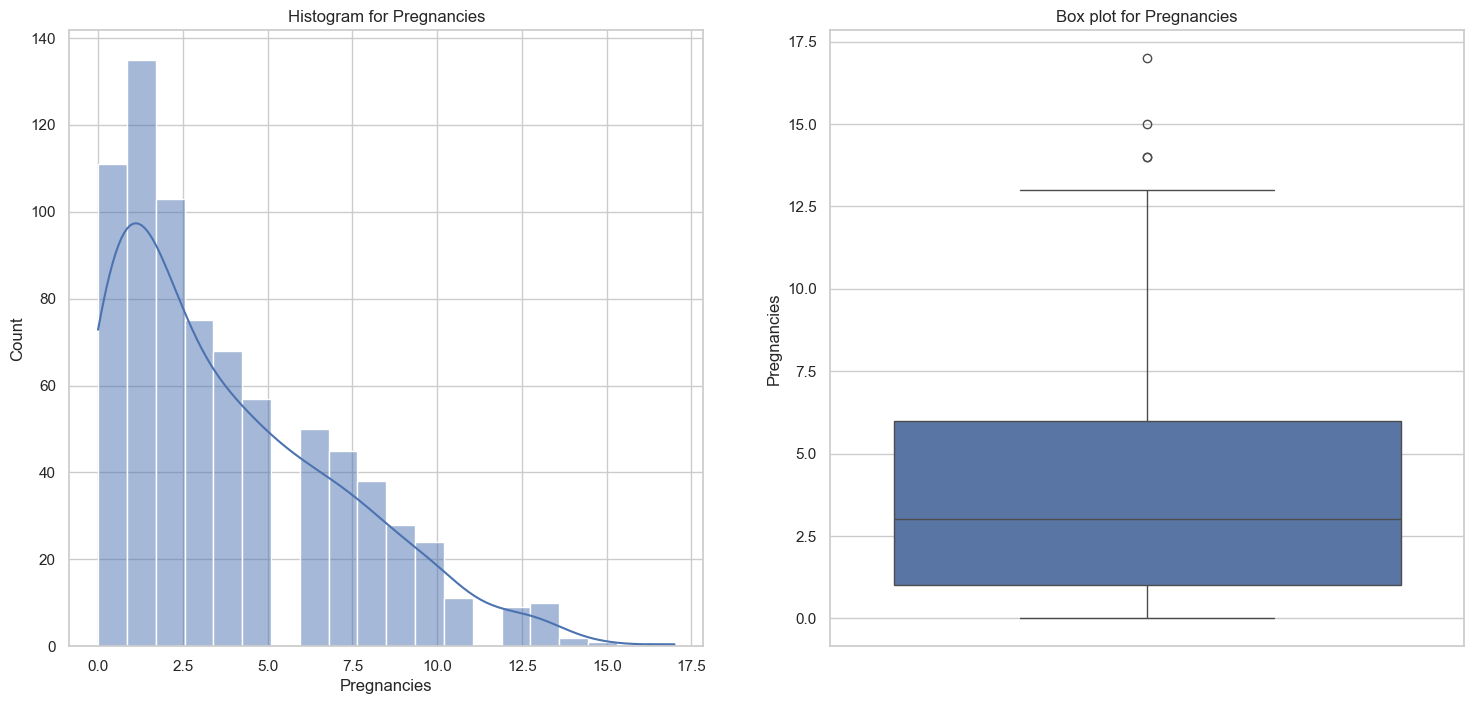

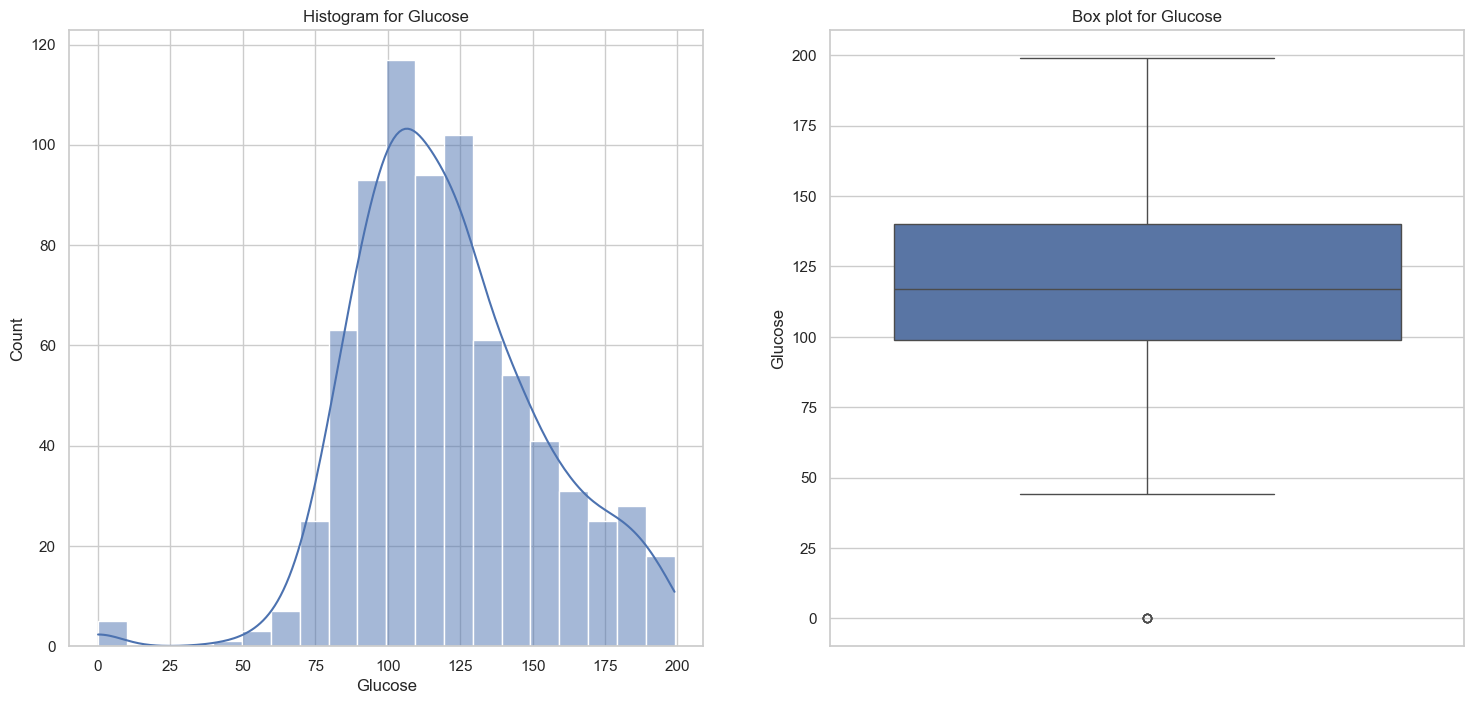

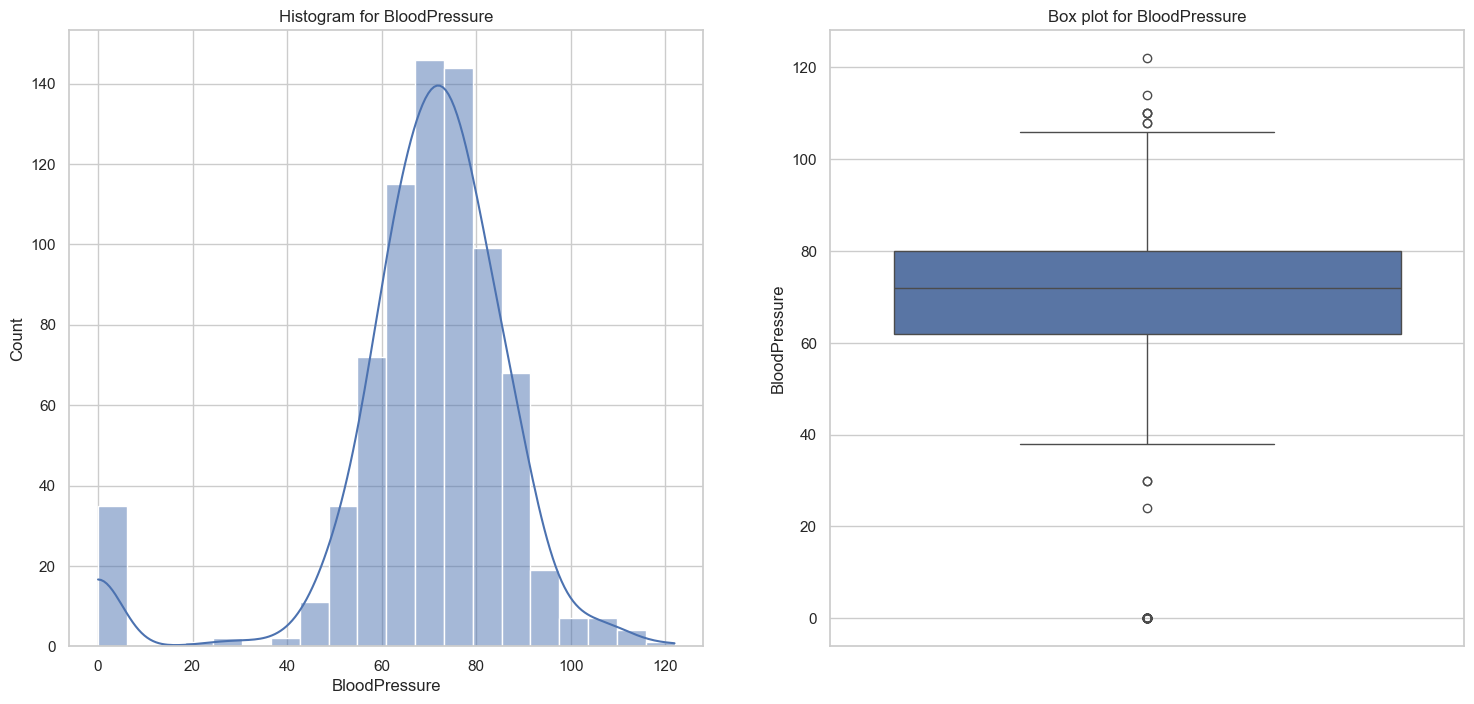

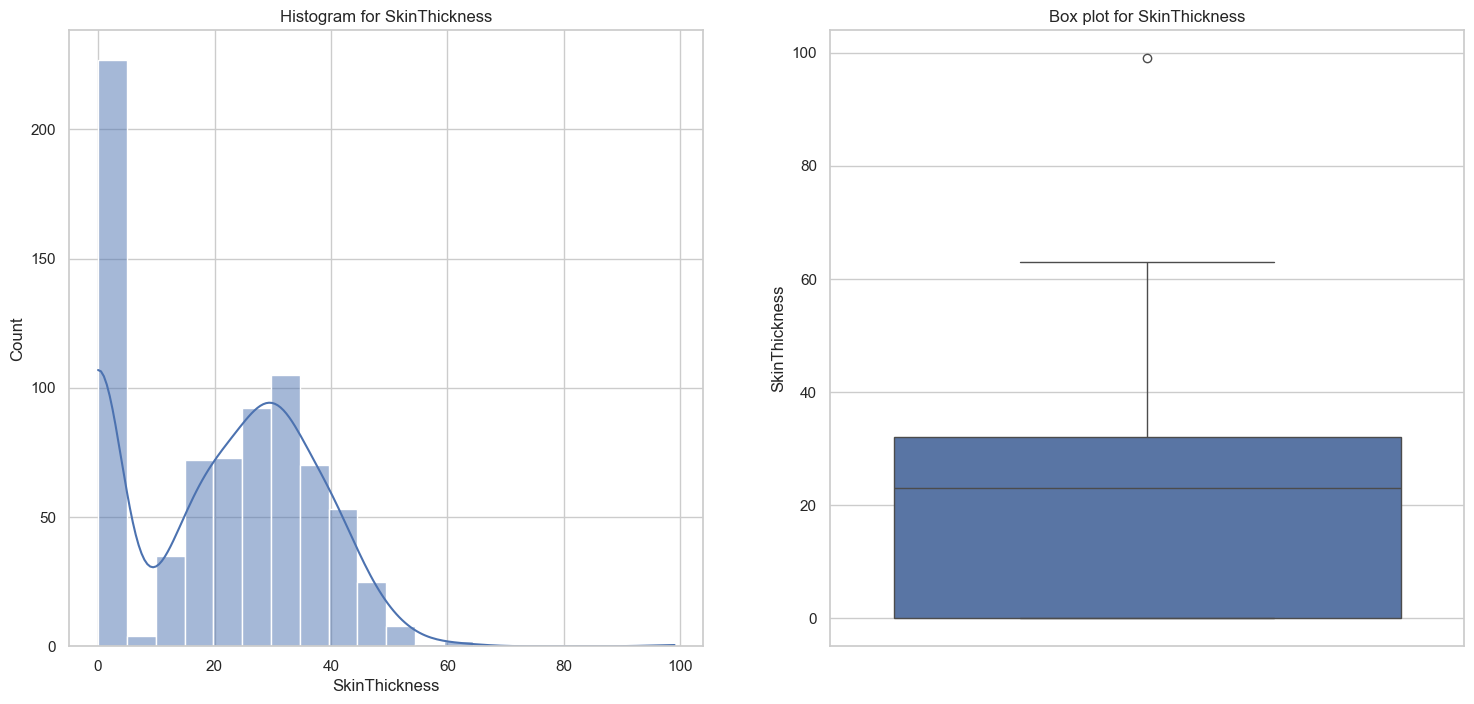

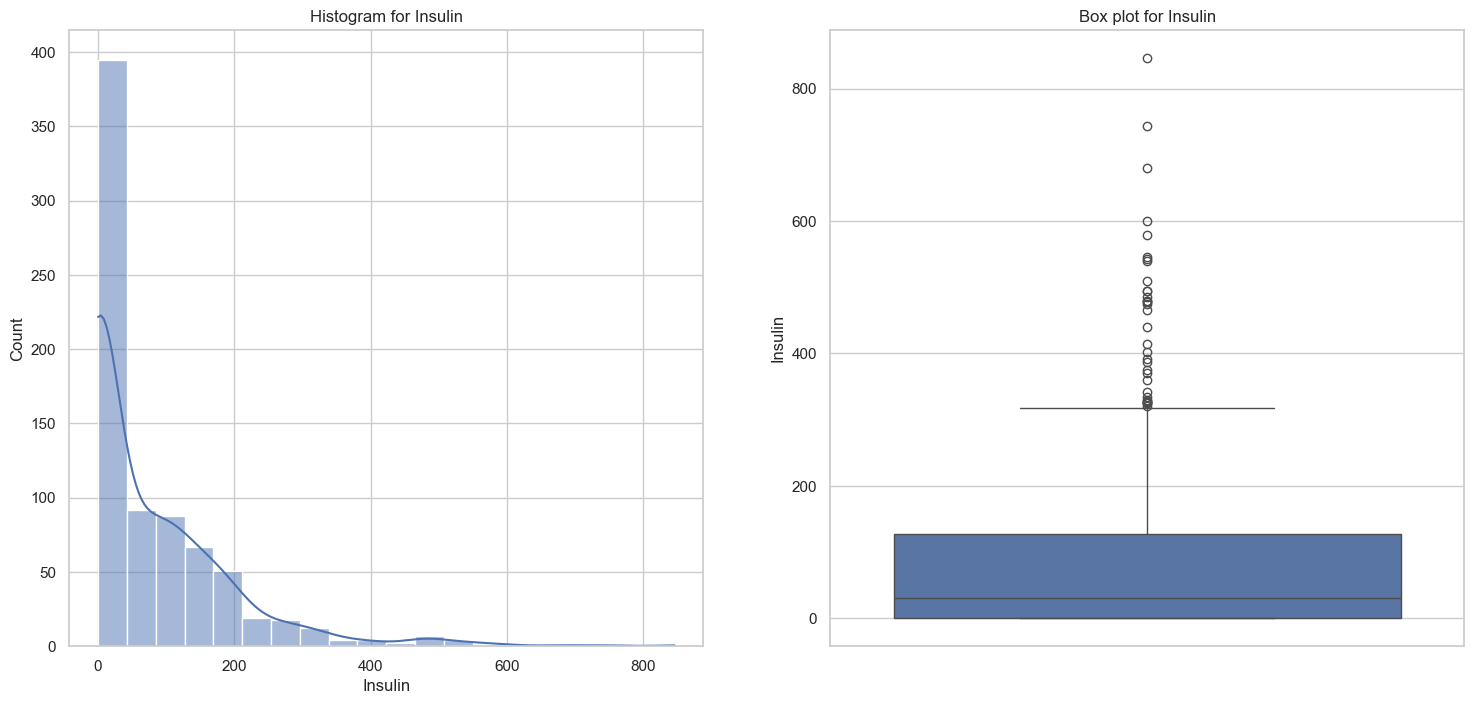

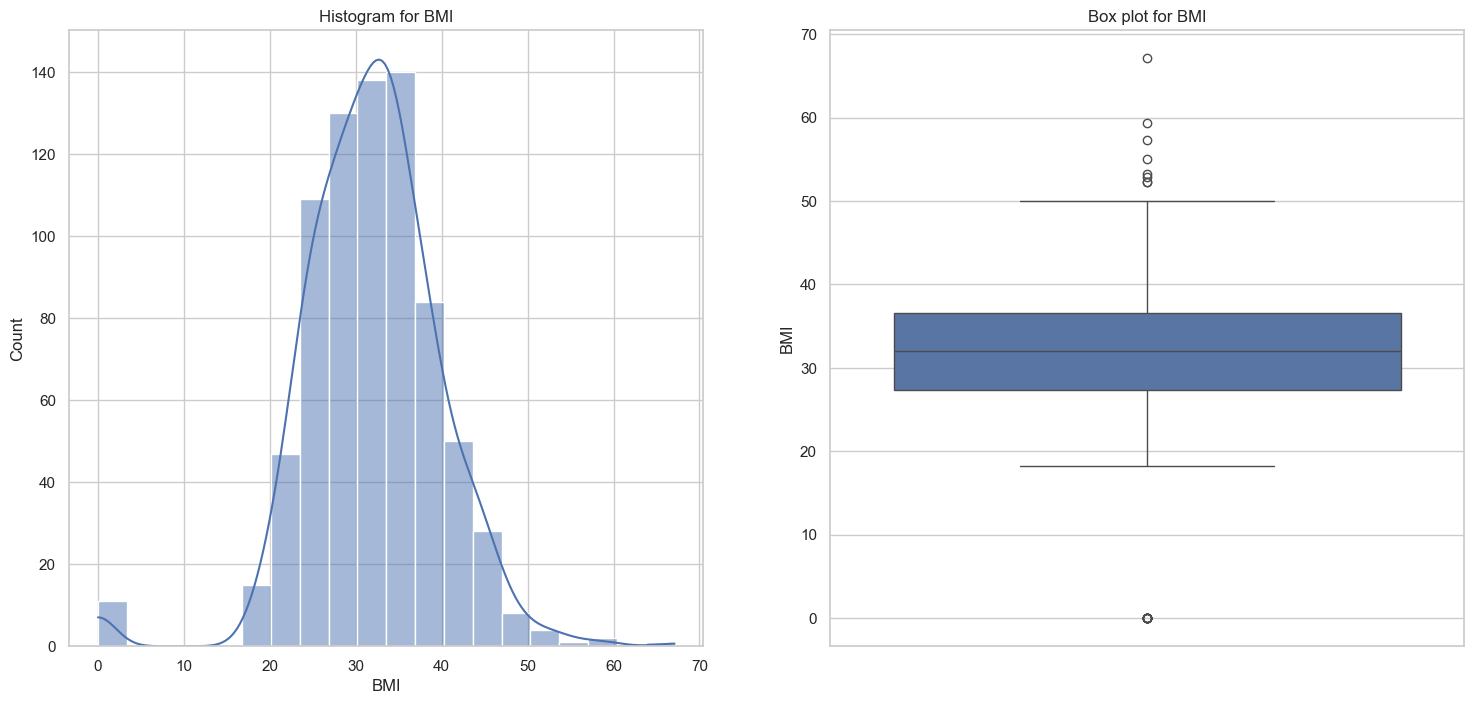

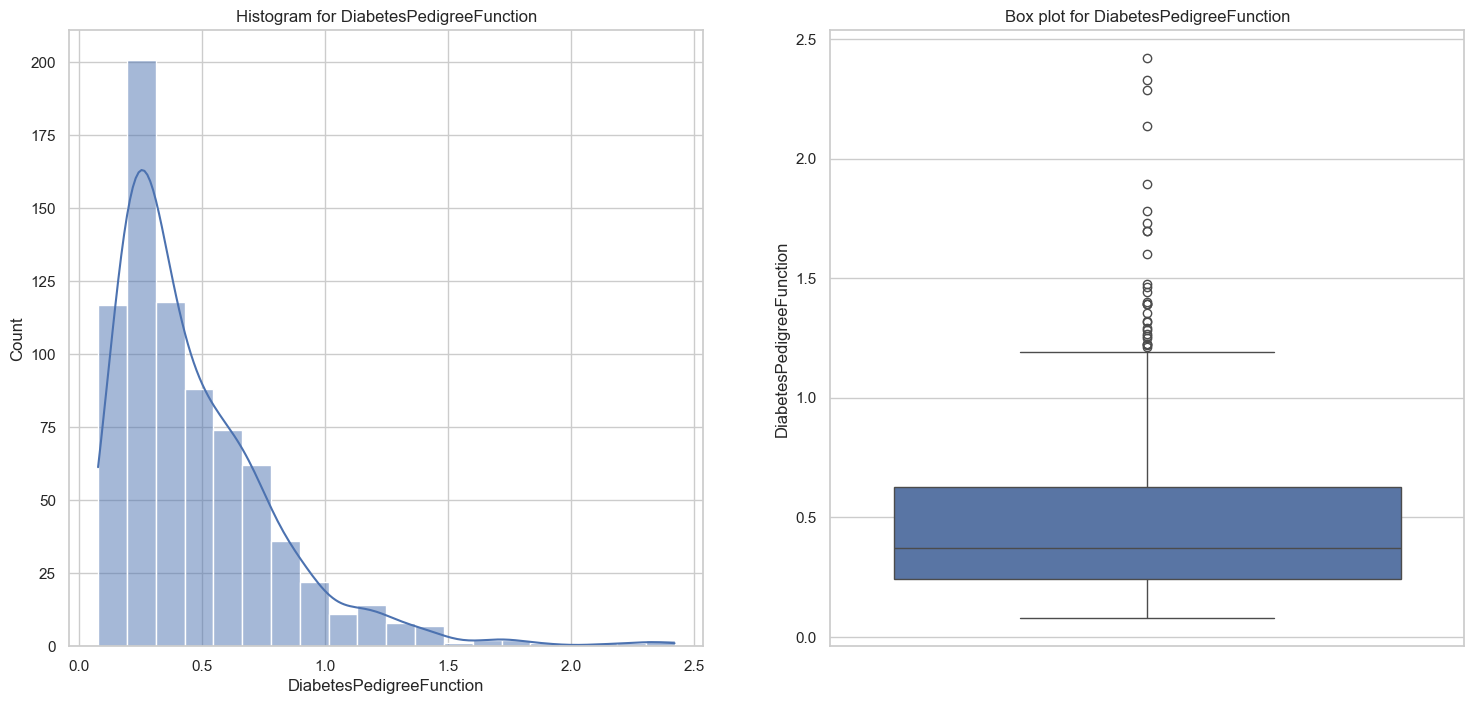

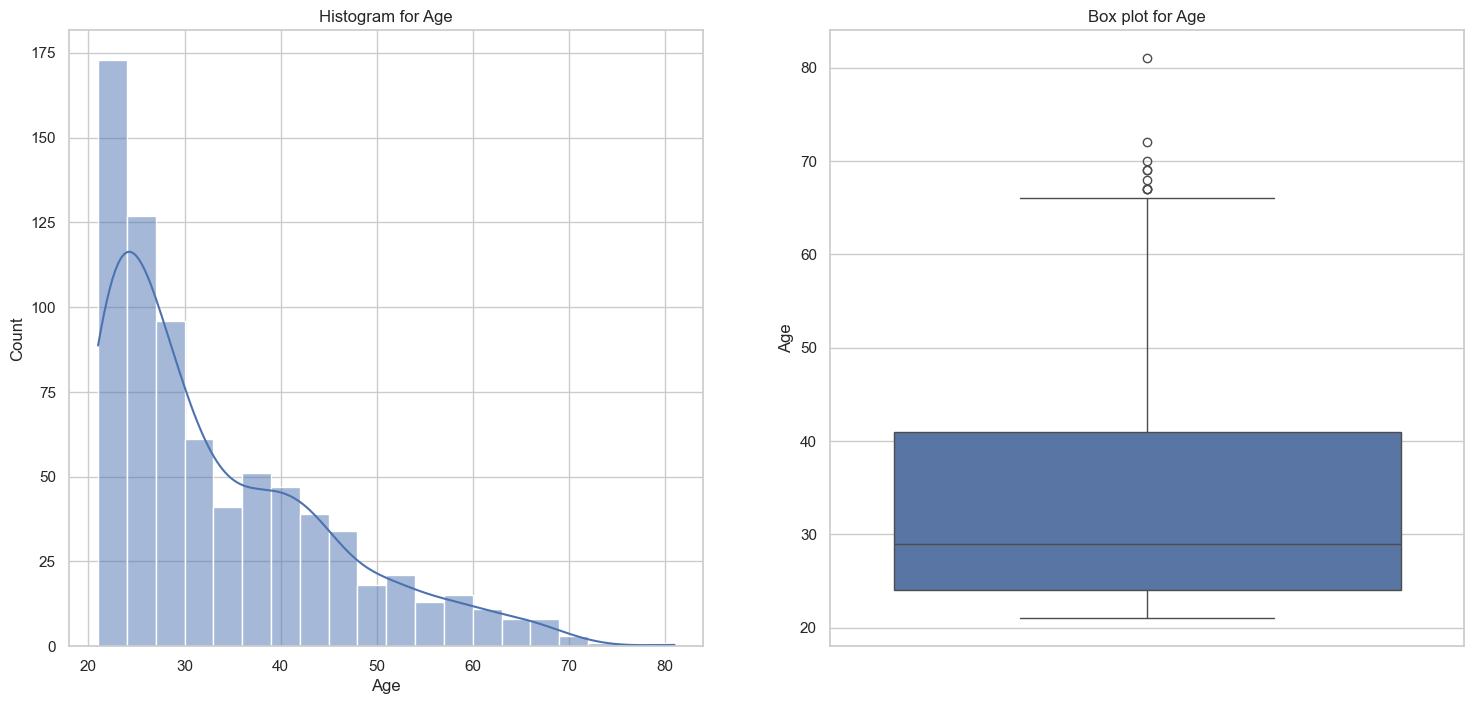

In [2]:
#univariate Analysis

numerical_cols = dataset.select_dtypes(include=["number"]).columns.tolist()
numerical = [col for col in  numerical_cols if not col == 'Outcome']
categorical_col = 'Outcome' # it's a categorical value eg,0, 1
print(numerical)

sns.set(style="whitegrid")
for col in numerical:
    plt.figure(figsize=(18,8))

    plt.subplot(1,2,1)
    plt.title(f"Histogram for {col}")
    sns.histplot(dataset[col], kde=True, bins=20)

    plt.subplot(1,2,2)
    plt.title(f"Box plot for {col}")
    sns.boxplot(dataset[col])

    plt.show()
    

    

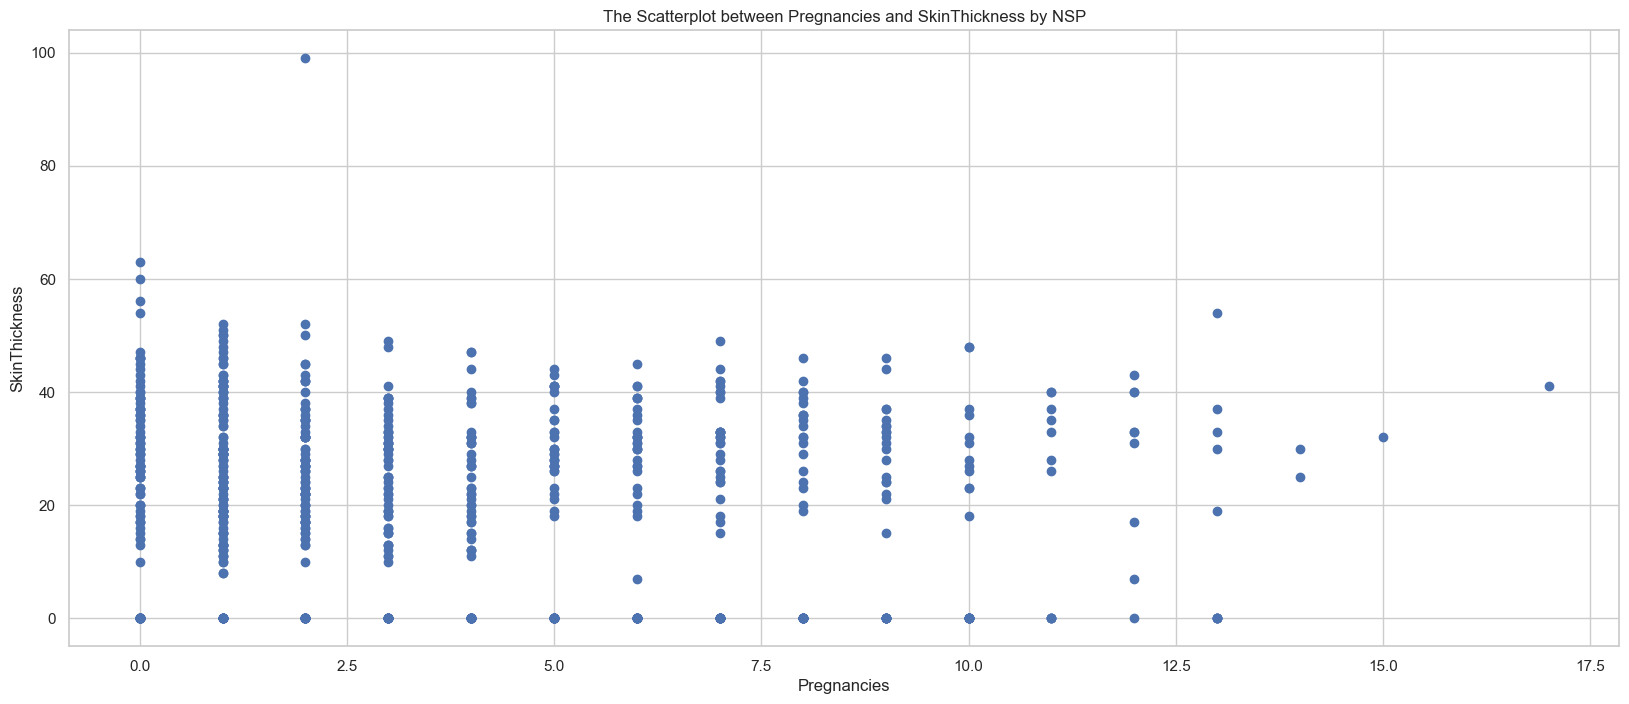

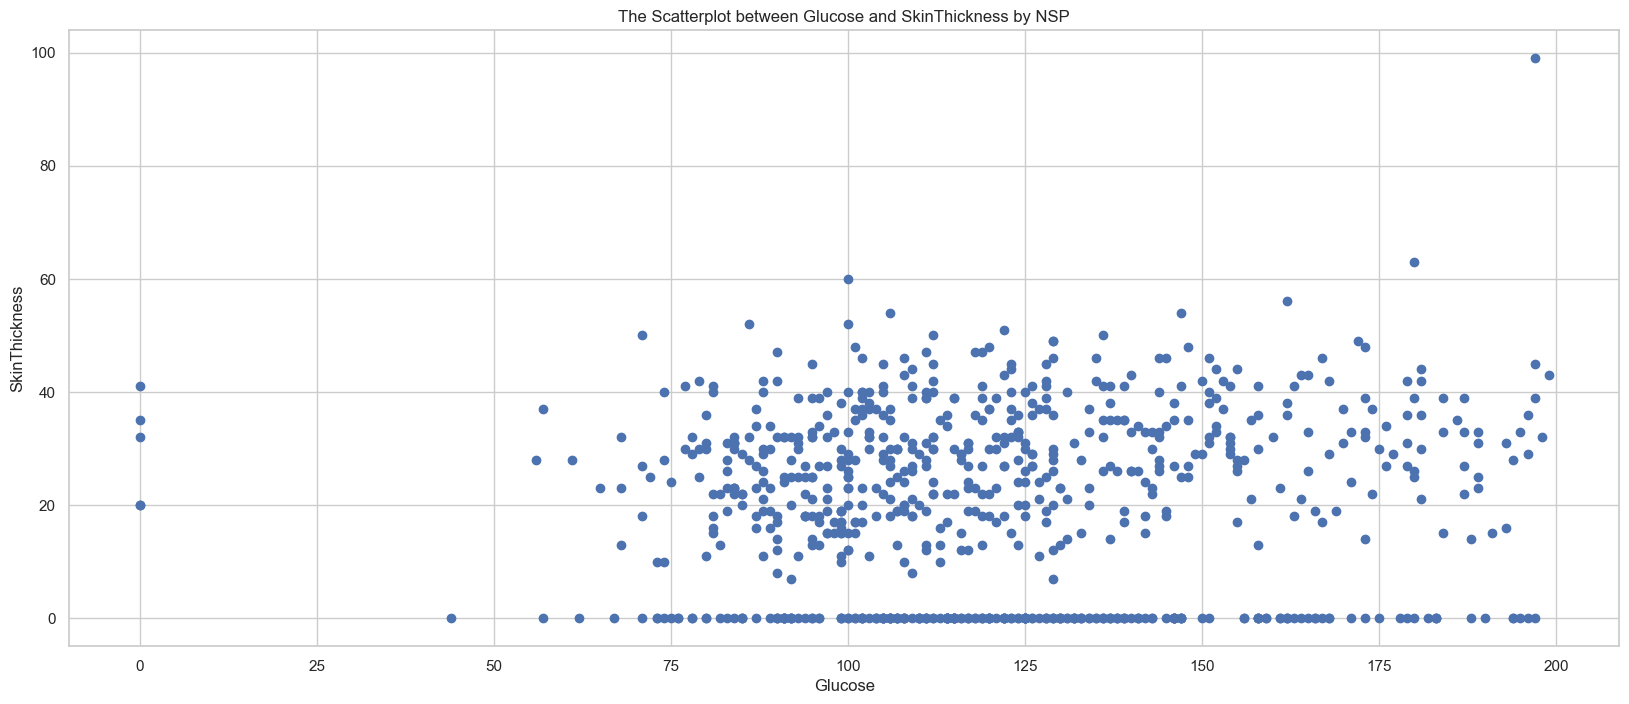

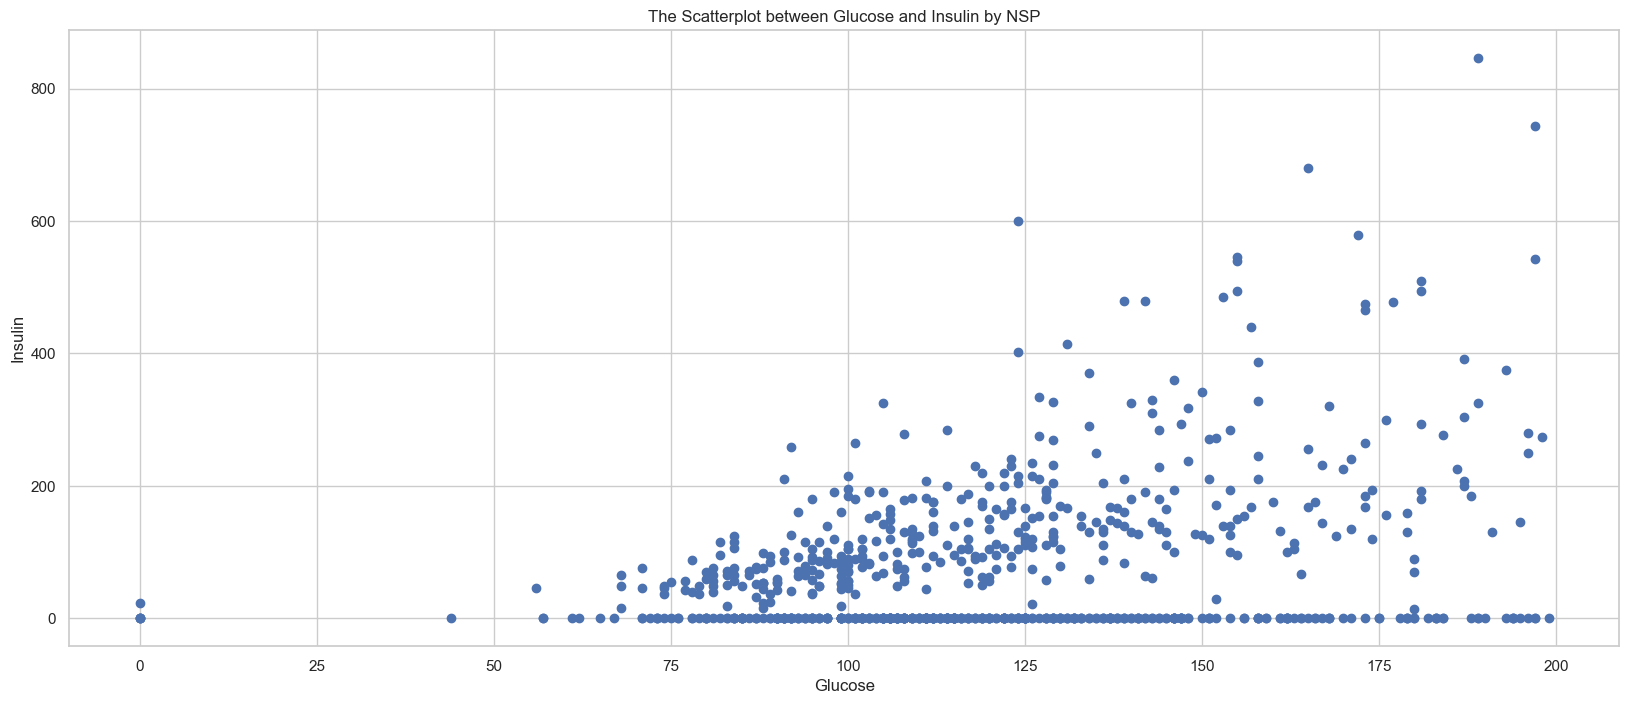

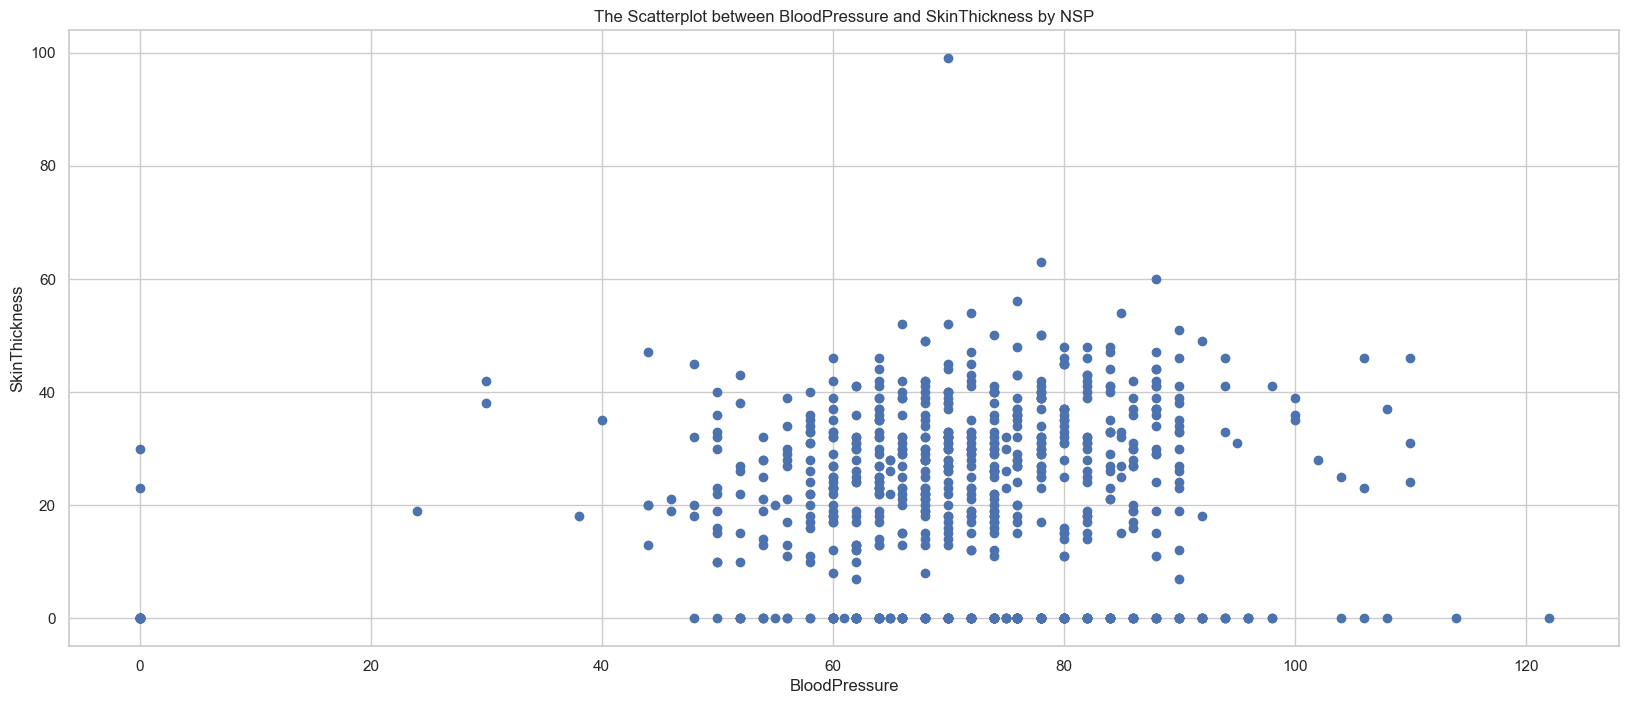

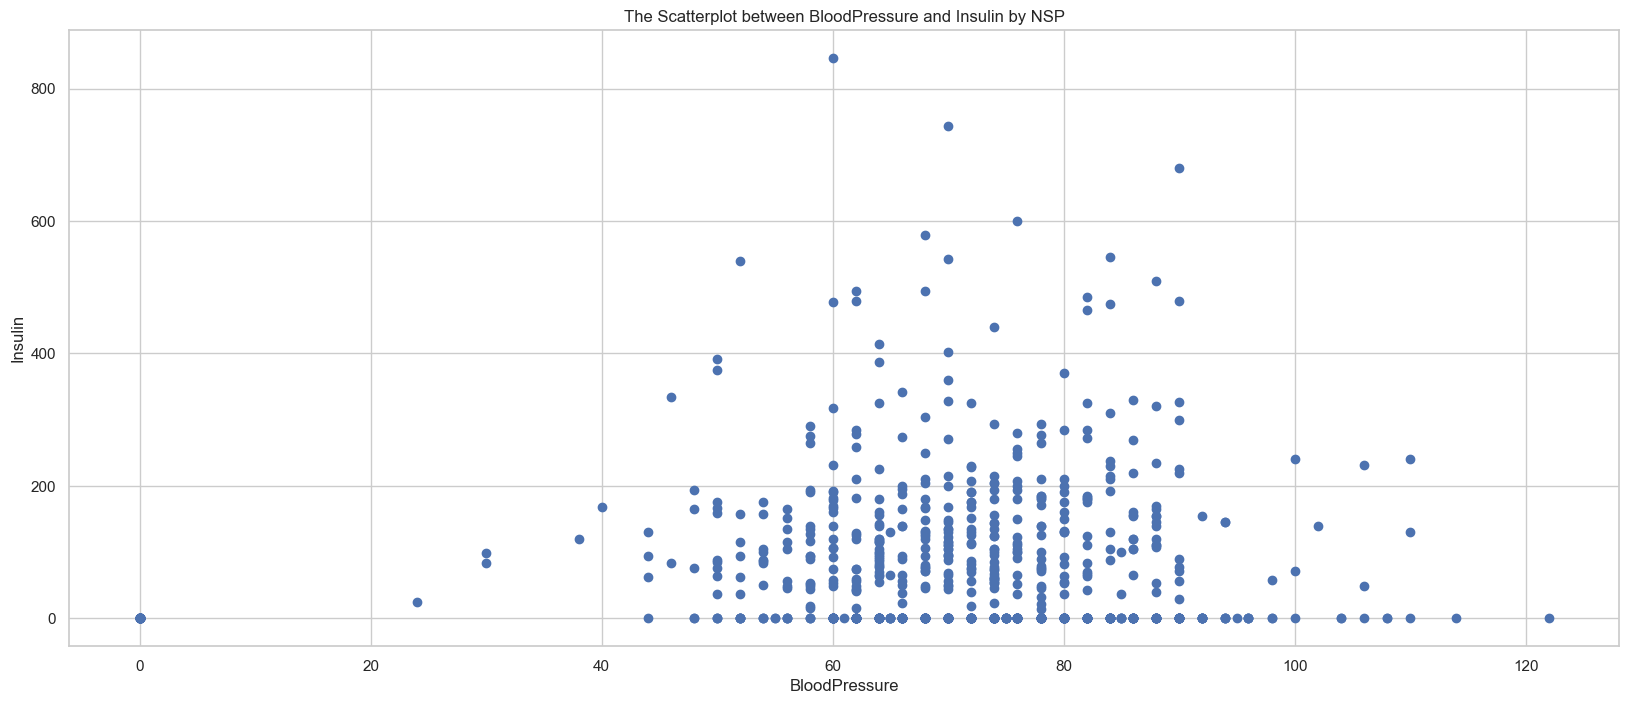

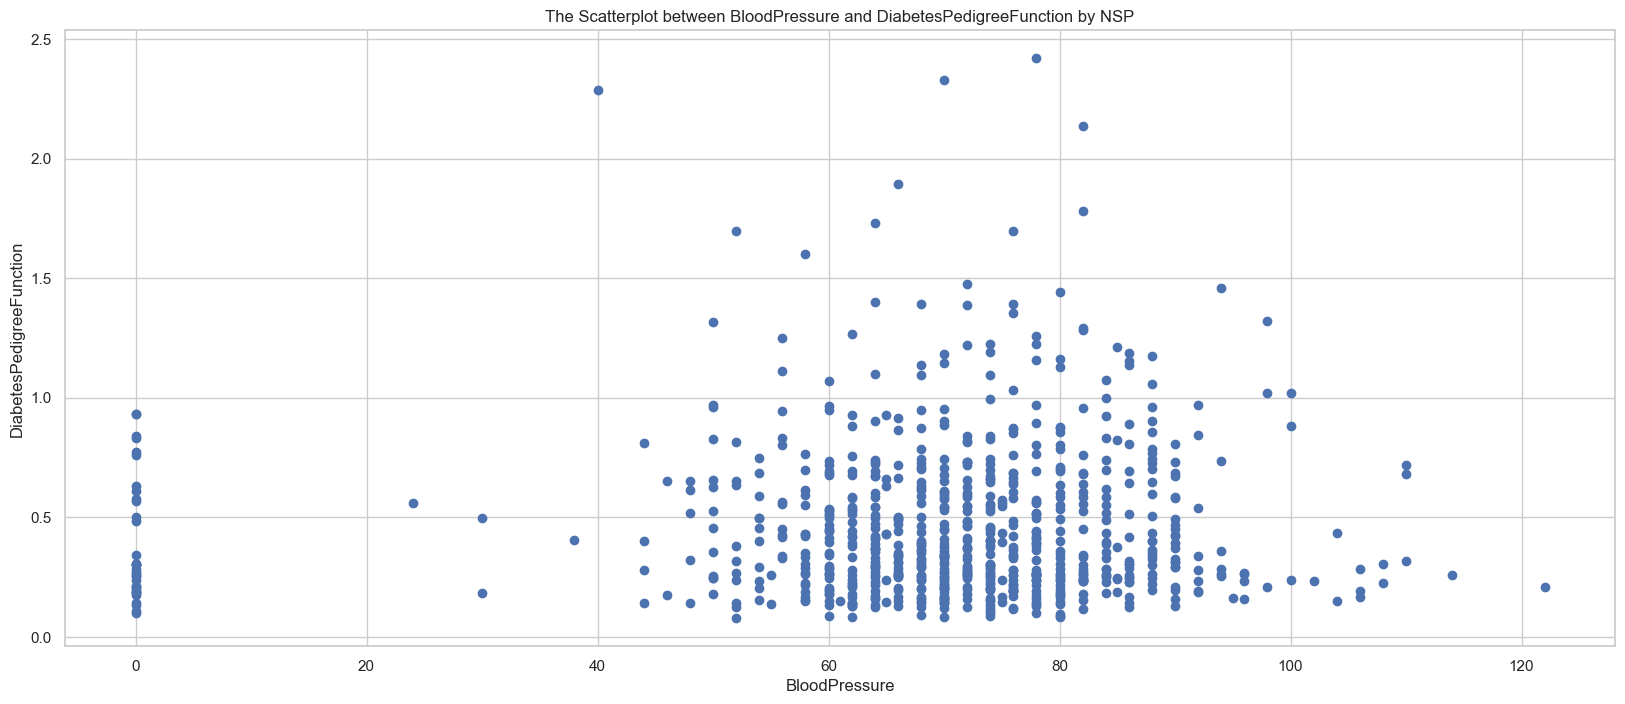

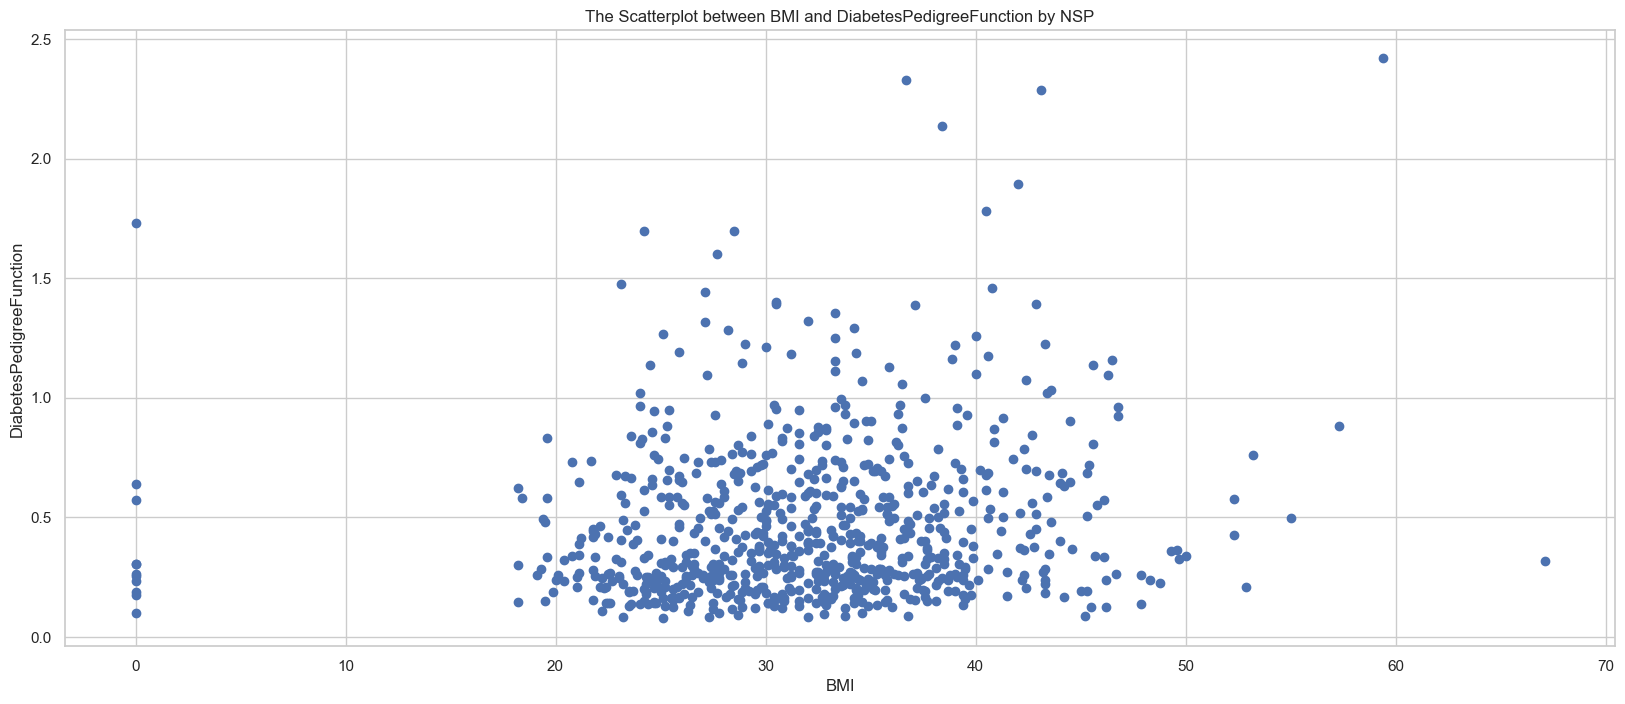

In [3]:
# scatterplot between all possible numerical cols
for i, x_col in enumerate(numerical):
    for y_col in numerical[i+1:]:
          if x_col < y_col:
            plt.figure(figsize=(20,8))
            plt.title(f"The Scatterplot between {x_col} and {y_col} by NSP")
            plt.xlabel(x_col)
            plt.ylabel(y_col)
            plt.scatter(x=x_col, y=y_col, data=dataset)
            plt.show()

```
2. Data Preprocessing:
a. Handle missing values (e.g., imputation).
b. Encode categorical variables.
```

In [4]:
# Some columns in the table have unrealistic values like 0, in the Bloodpressure, skinthickness, insulin and BMI
cols_with_zero_invalid = ['BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
dataset[cols_with_zero_invalid] = dataset[cols_with_zero_invalid].replace(0,np.nan)

# Filling the missing values
for col in cols_with_zero_invalid:
    dataset.fillna(dataset[col].median(),inplace=True)

print(dataset)
    

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148           72.0           35.0     72.0  33.6   
1              1       85           66.0           29.0     72.0  26.6   
2              8      183           64.0           72.0     72.0  23.3   
3              1       89           66.0           23.0     94.0  28.1   
4              0      137           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101           76.0           48.0    180.0  32.9   
764            2      122           70.0           27.0     72.0  36.8   
765            5      121           72.0           23.0    112.0  26.2   
766            1      126           60.0           72.0     72.0  30.1   
767            1       93           70.0           31.0     72.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

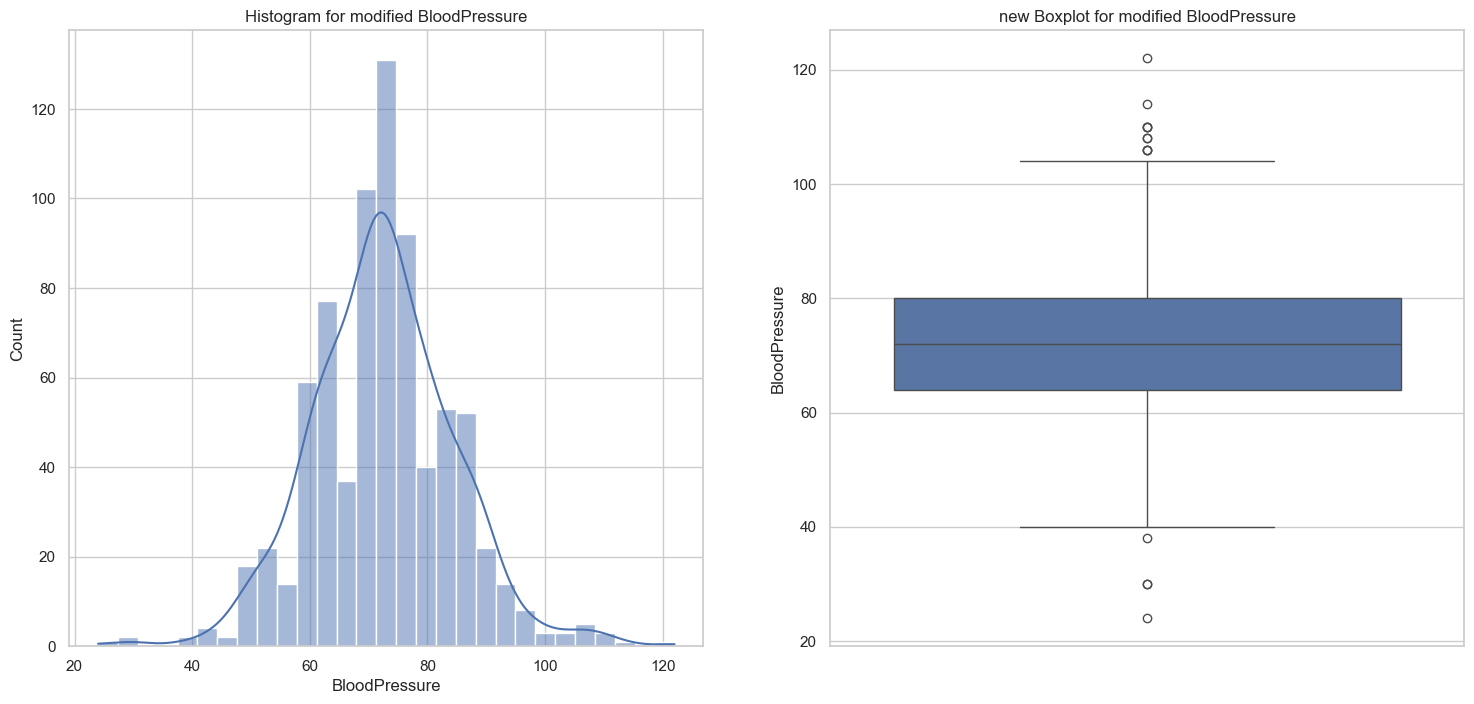

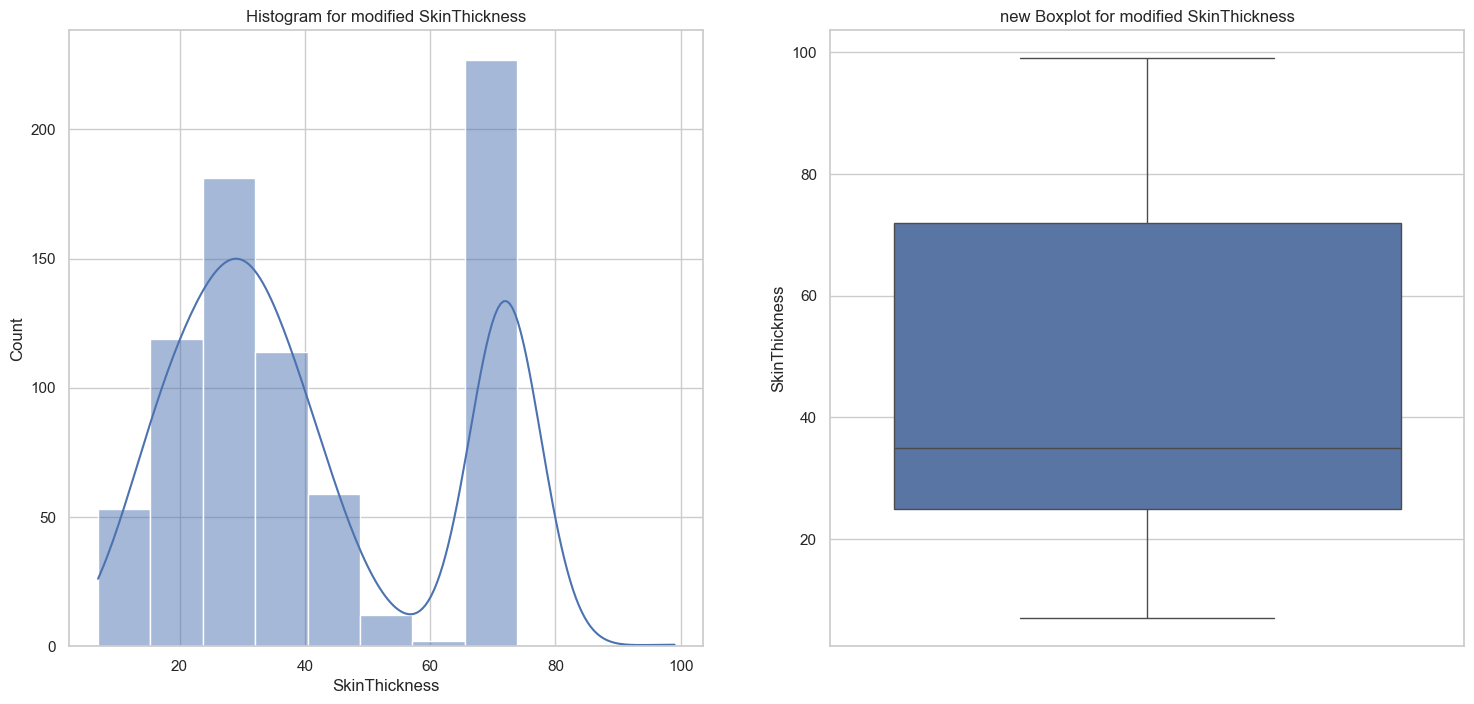

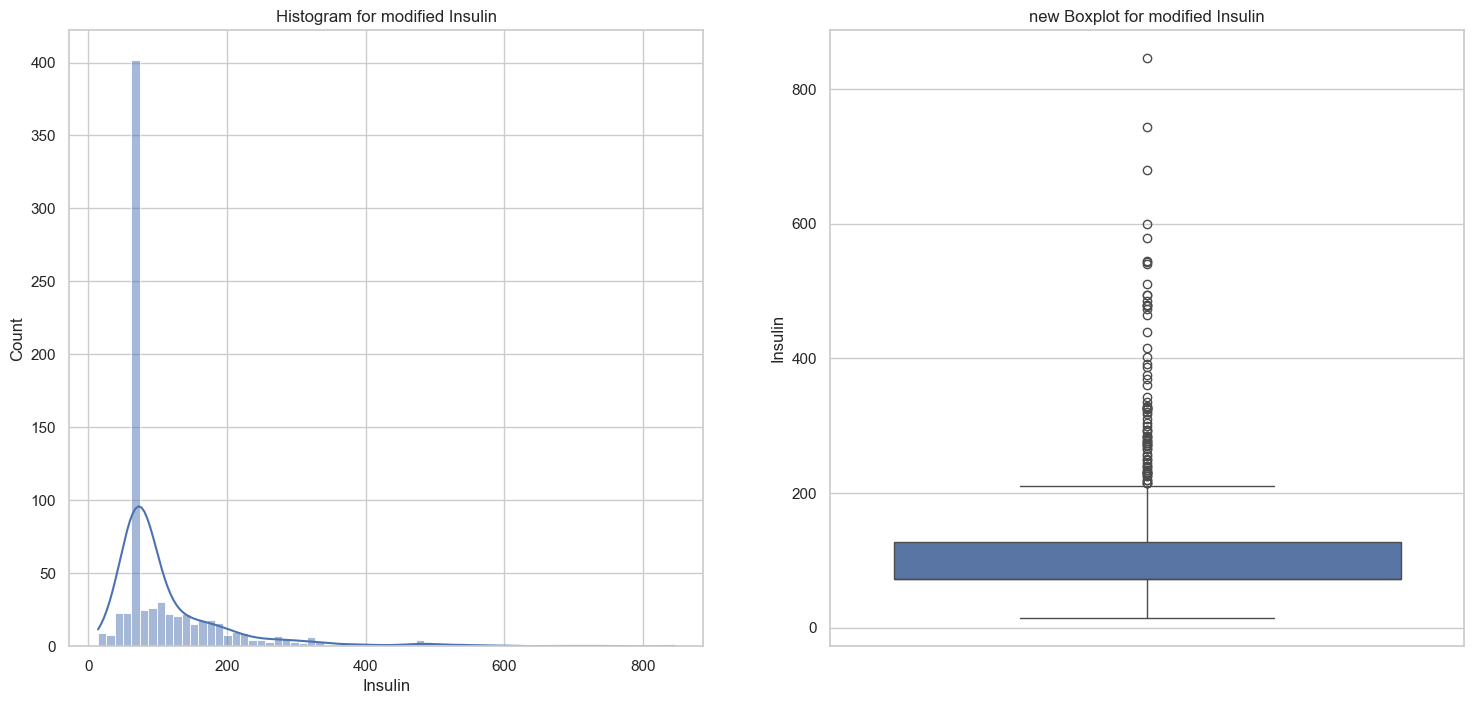

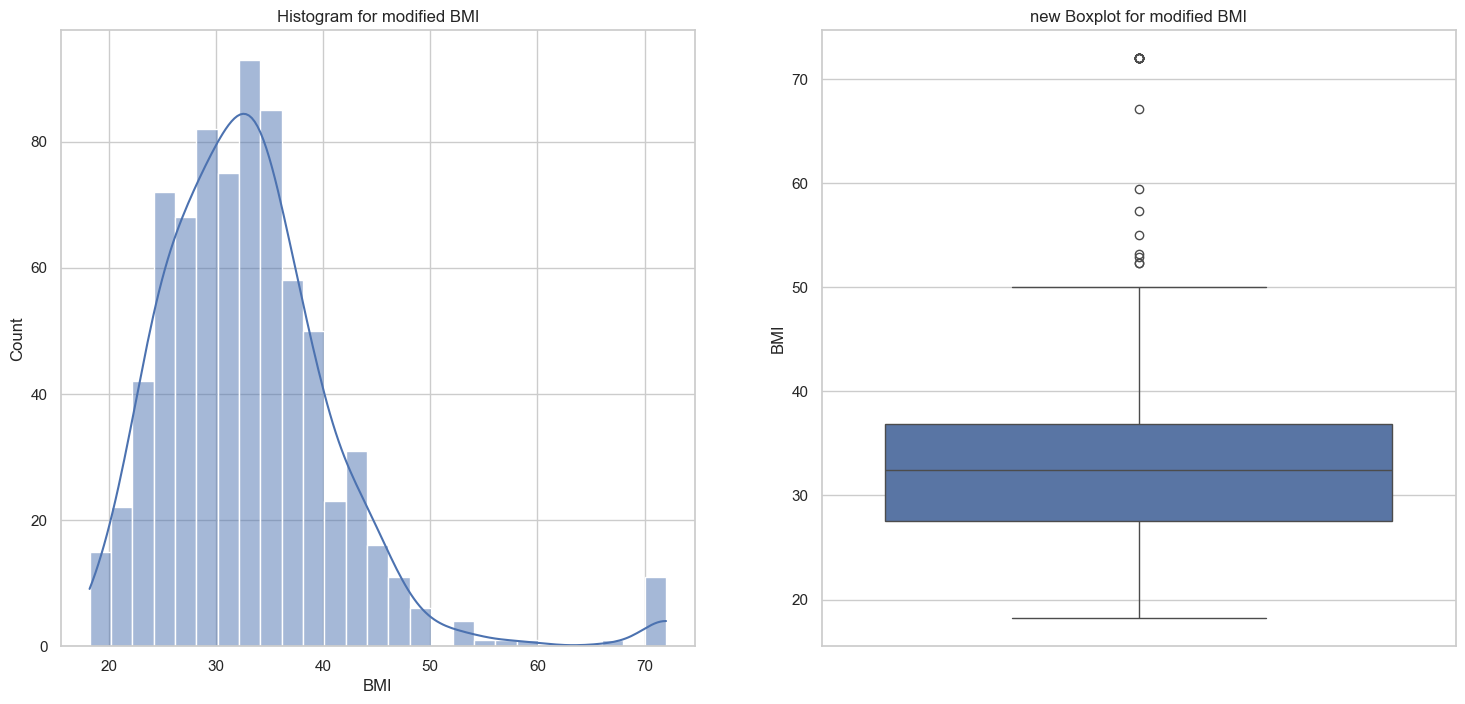

In [5]:
# Boxplot and histogram for the modified columns 
for col in cols_with_zero_invalid:
    plt.figure(figsize=(18,8))

    plt.subplot(1,2,1)
    sns.histplot(dataset[col],kde=True)
    plt.title(f"Histogram for modified {col}")

    plt.subplot(1,2,2)
    plt.title(f"new Boxplot for modified {col}")
    sns.boxplot(dataset[col])

    plt.show()

In [6]:

numeric_cols = [col for col in dataset.columns.tolist() if not col == 'Outcome']

for col in numeric_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping directly on dataset
    dataset[col] = dataset[col].clip(lower=lower_bound, upper=upper_bound)



<-----Boxplot after removing all the outliers------>



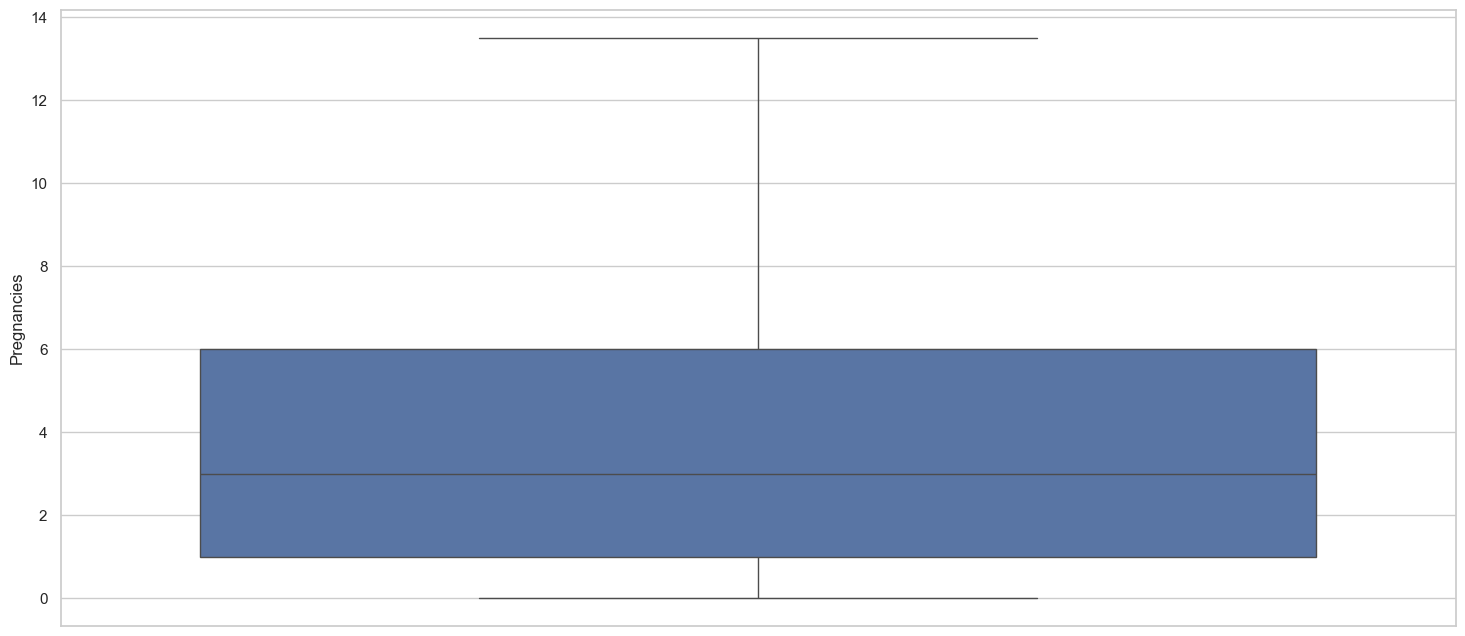

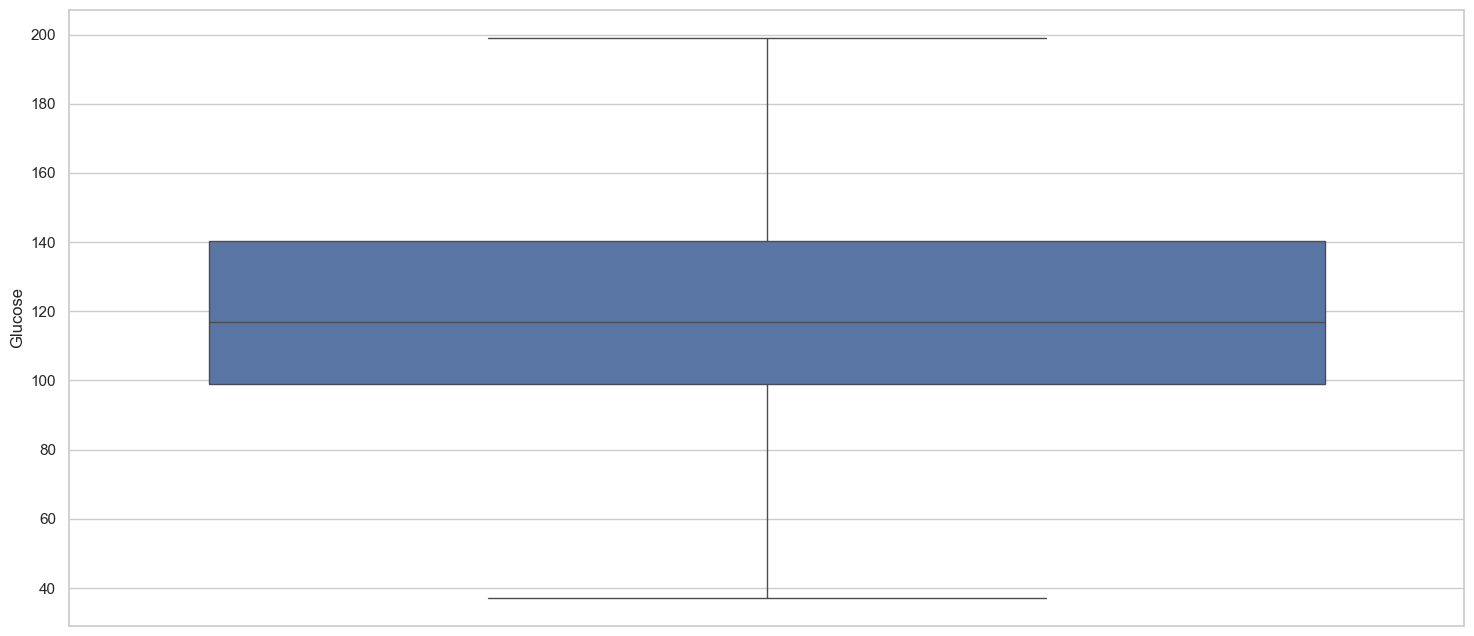

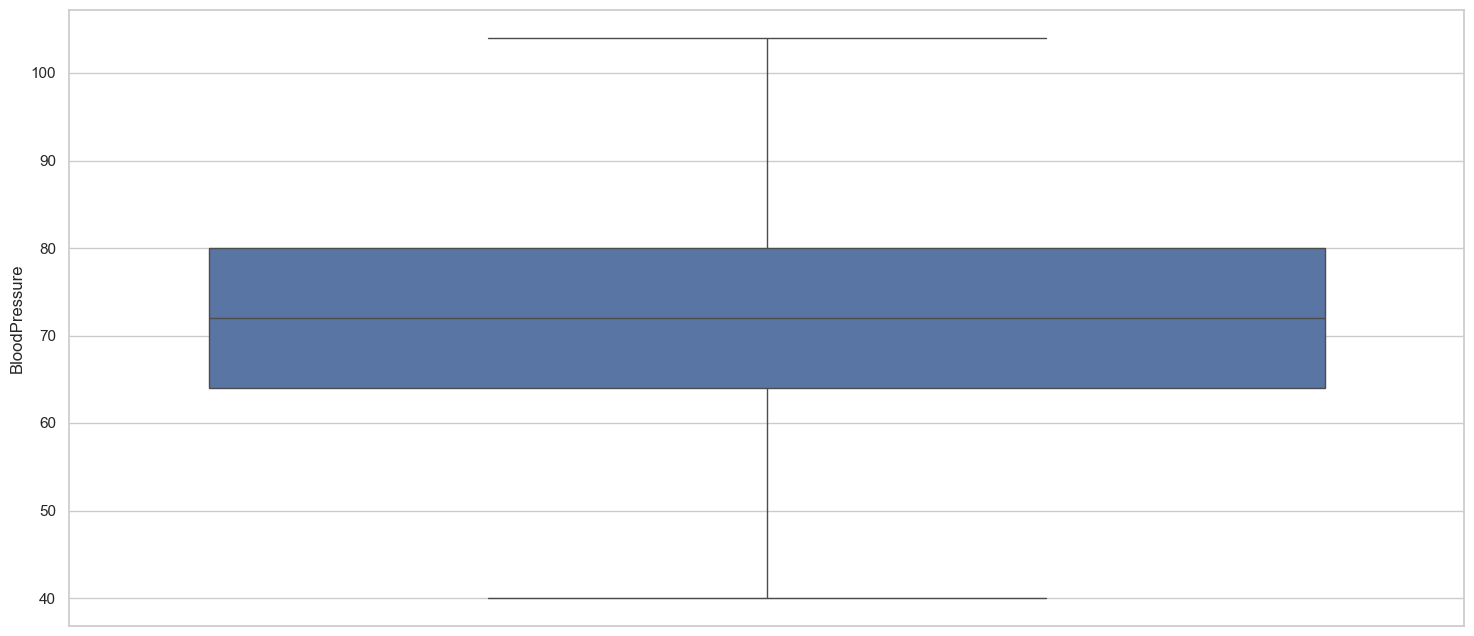

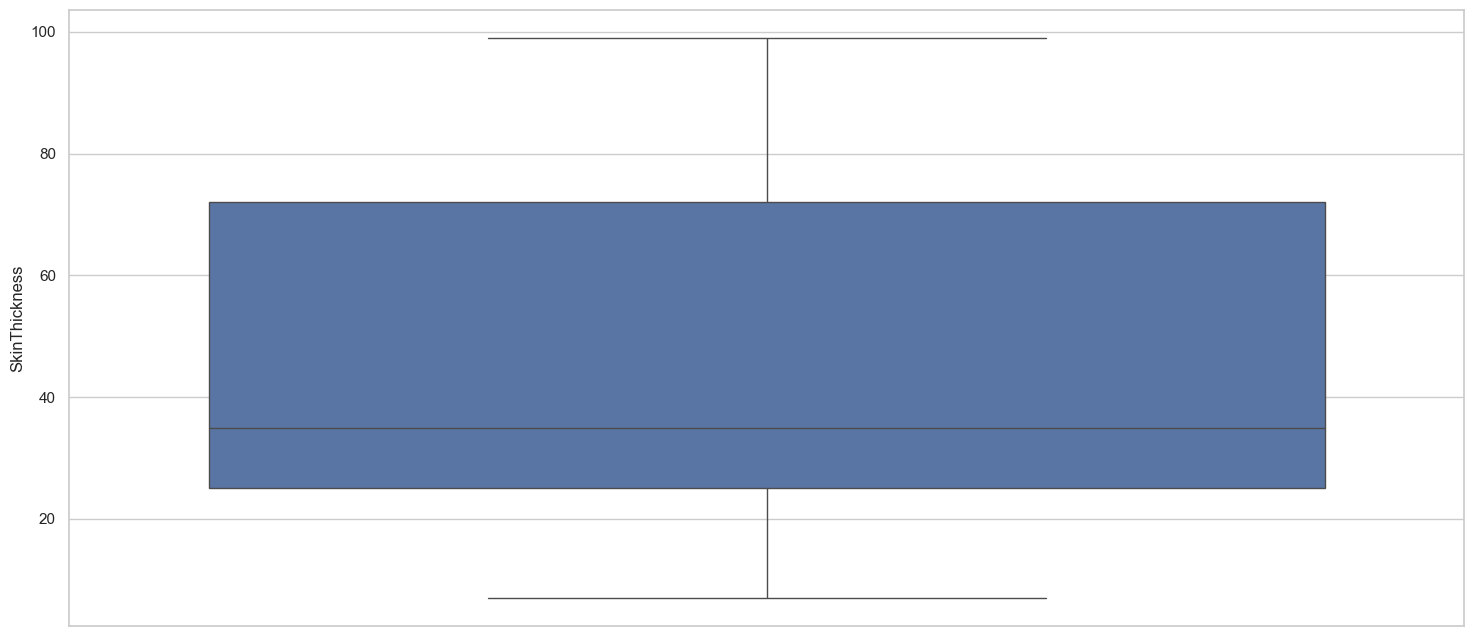

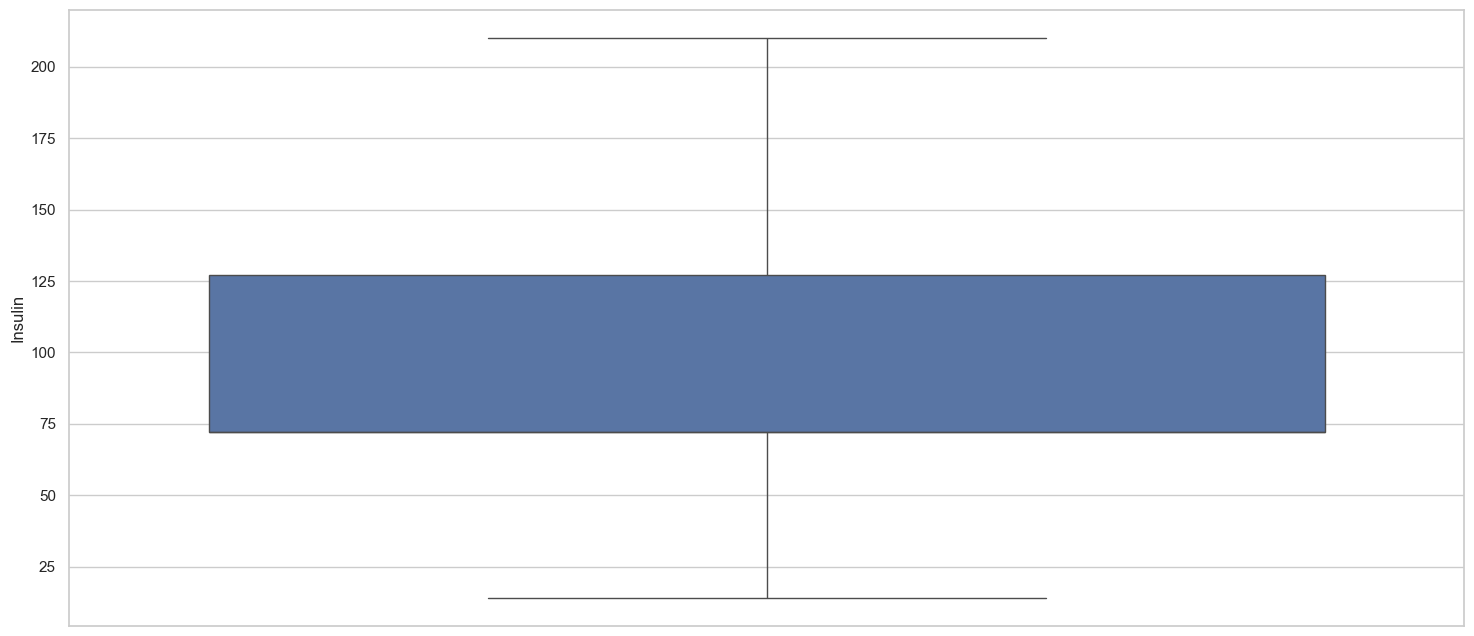

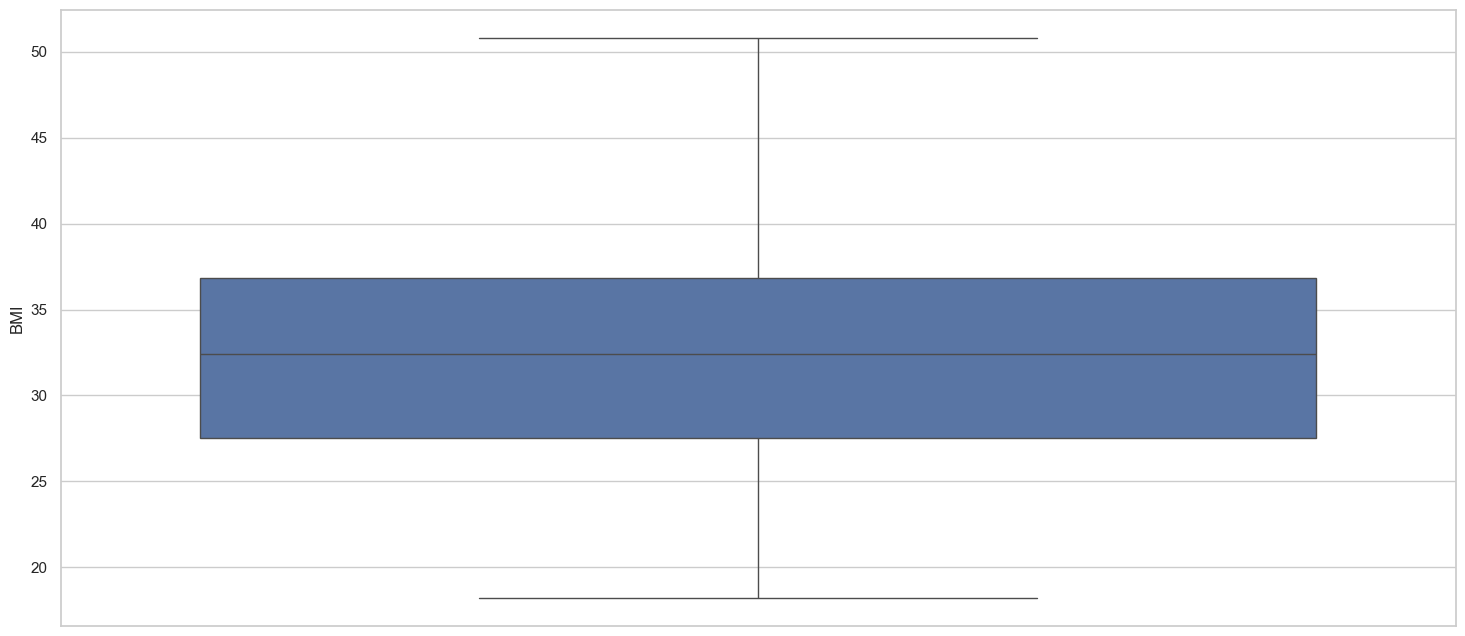

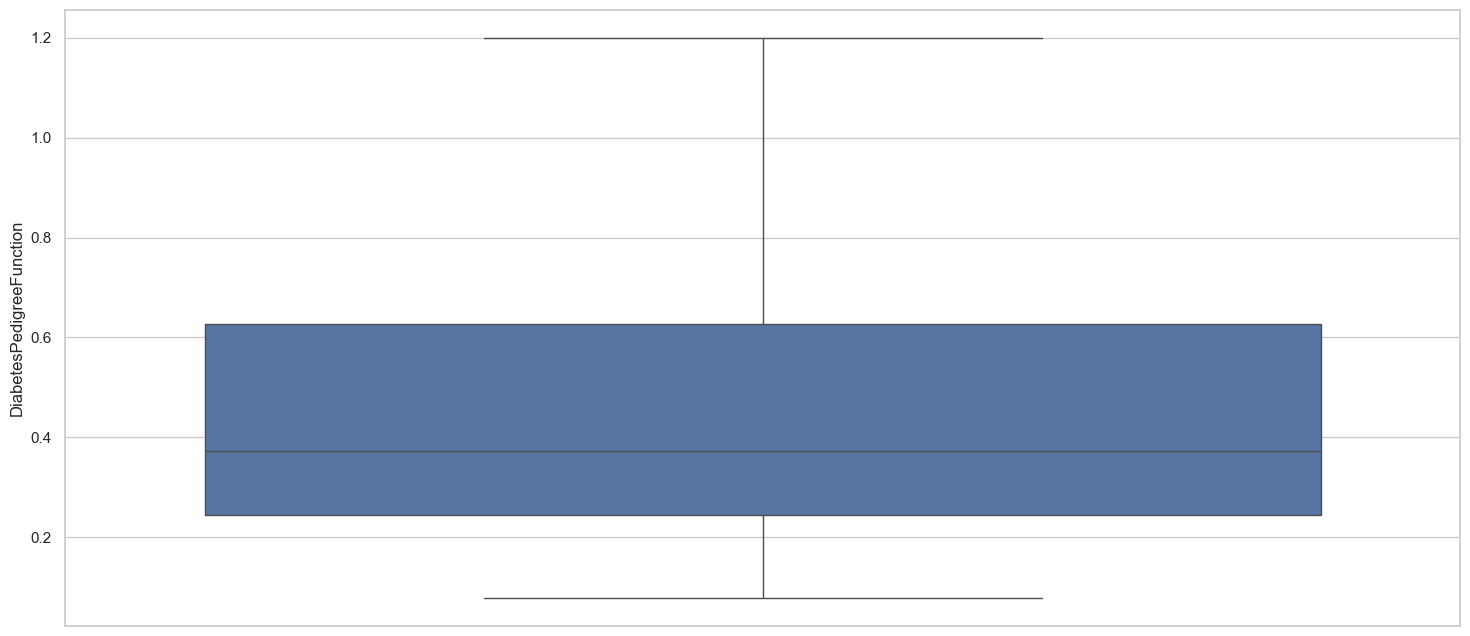

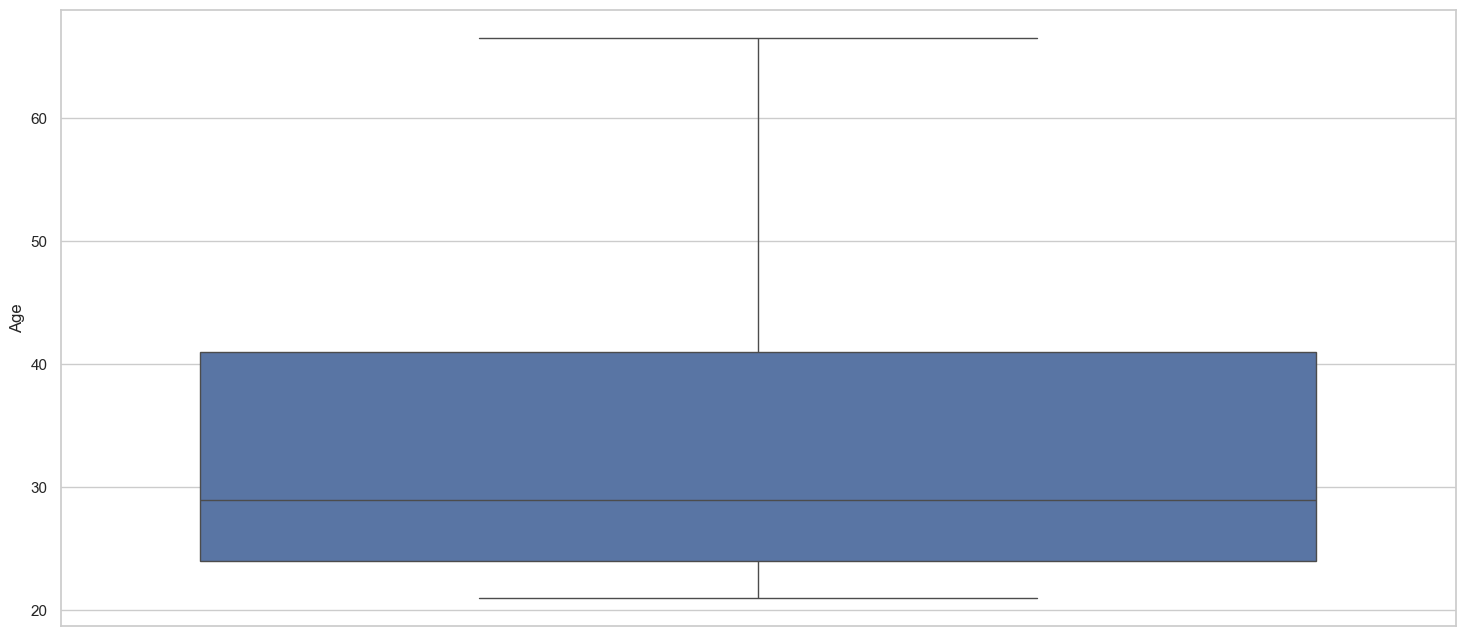

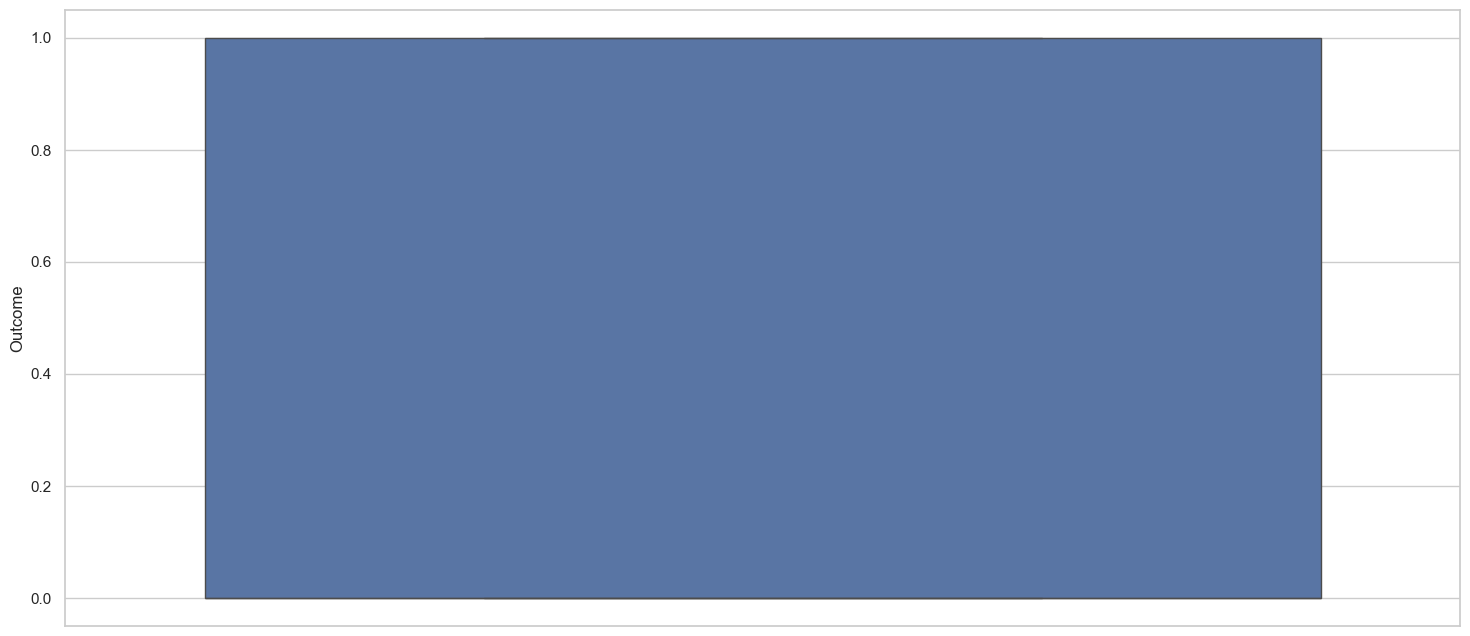

In [7]:
# Again checking whether outliers are there or not by using box plot
print("\n<-----Boxplot after removing all the outliers------>\n")
for col in numerical_cols:
    plt.figure(figsize=(18,8))
    sns.boxplot(dataset[col])
    

    plt.show()

```
3. Model Building:
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
b. Train the model using the training data.
```

In [13]:
# Dividing Data into features and target
X = dataset[[col for col in dataset.columns.tolist() if not col == 'Outcome']]
y = dataset['Outcome']

In [15]:
#Train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42,stratify=y)


In [17]:
# Feature Scaling(standardization)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
# Using GridSearchCV with Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression()

parameters = {
    'penalty':['l1', 'l2', 'elasticnet'],
    'C':[0.01, 0.1, 1, 2,3,4,5,10,100],
    'max_iter':[100,200,300,400,500],
    'solver':['liblinear','saga']
}

# Using GridSearchCV
logistic_regressor = GridSearchCV(log_reg, parameters, scoring="accuracy", cv=5 )
logistic_regressor.fit(X_train,y_train)


C:\Users\mdrud\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
450 fits failed out of a total of 1350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
225 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\mdrud\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\mdrud\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\mdrud\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 2, 3, 4, 5, 10, 100],
                         'max_iter': [100, 200, 300, 400, 500],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [25]:
print("best parameters", logistic_regressor.best_params_)
print("Best CV Accuracy:", logistic_regressor.best_score_)

best parameters {'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.7820483533219112


```
4. Model Evaluation:
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.
```

In [28]:
# Evaluating model
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

best_model = logistic_regressor.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy is:",accuracy_score(y_test,y_pred))
print("\n<------Classificationn Report------->\n",classification_report(y_test,y_pred))

#Predicted probabilities for the positive class
y_pred_prob = best_model.predict_proba(X_test)[:,1]
print("ROC-AUC score:", roc_auc_score(y_test,y_pred_prob))

Test Accuracy is: 0.7283464566929134

<------Classificationn Report------->
               precision    recall  f1-score   support

           0       0.76      0.85      0.80       165
           1       0.64      0.51      0.57        89

    accuracy                           0.73       254
   macro avg       0.70      0.68      0.68       254
weighted avg       0.72      0.73      0.72       254

ROC-AUC score: 0.825672454885938


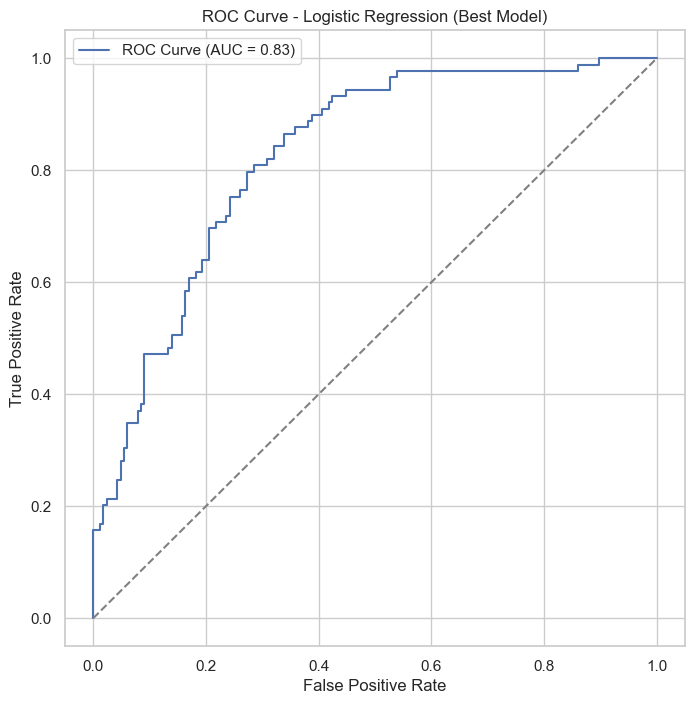

In [29]:
# Vizualizing ROC_AUC curve
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve, roc_auc_score

#Computing Roc Curve
fpr, tpr, threshold = roc_curve(y_test, y_pred_prob)

# Plot ROC Curve
plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Best Model)")
plt.legend()
plt.show()

```
5. Interpretation:
a. Interpret the coefficients of the logistic regression model.
b. Discuss the significance of features in predicting the target variable (survival probability in this case).
```

In [33]:
import pandas as pd

coefficients = best_model.coef_[0] 

features = [col for col in dataset.columns.tolist() if not col == 'Outcome']

coef_df = pd.DataFrame( {
    "Feature": features,
    "Coefficient (β)": coefficients,
    "Odds Ratio (exp(β))": np.exp(coefficients)
})

print(coef_df)

                    Feature  Coefficient (β)  Odds Ratio (exp(β))
0               Pregnancies         0.316743             1.372650
1                   Glucose         0.947230             2.578558
2             BloodPressure         0.000000             1.000000
3             SkinThickness         0.000000             1.000000
4                   Insulin         0.000000             1.000000
5                       BMI         0.487933             1.628946
6  DiabetesPedigreeFunction         0.143332             1.154112
7                       Age         0.026398             1.026750


## Disscussing the significance of features
```
1. Pregnancies (β=0.317, OR≈1.37): Each extra pregnancy increases the odds of diabetes by 37%, keeping other factors constant.

2. Glucose (β=0.947, OR≈2.58): The most important predictor here — each unit increase in glucose multiplies the odds of diabetes by 2.6.

3. BloodPressure, SkinThickness, Insulin (β=0.0, OR=1.0): The model found no predictive power here, maybe due to scaling, collinearity, or regularization.

4. BMI (β=0.488, OR≈1.63): Higher BMI strongly increases odds of diabetes (63% increase per unit).

5. DiabetesPedigreeFunction (β=0.143, OR≈1.15): A genetic/family risk factor — modest but positive effect.

6. Age (β=0.026, OR≈1.03): Each extra year increases odds by 3%.
```

## Deployment Locally:

```
6. Deployment with Streamlit:
In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions.
```

In [34]:
import pickle

with open("log_reg_diabetes.pkl", "wb") as file:
    pickle.dump(best_model, file)